In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()  # устанавливаем seaborn по умолчанию для отрисовки графиков

In [3]:
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
train = pd.read_csv('/content/drive/MyDrive/AI/MushroomDataset/secondary_data.csv', sep=';')

In [5]:
train.head()

,class,cap-diameter,cap-shape,cap-surface,cap-color,does-bruise-or-bleed,gill-attachment,gill-spacing,gill-color,stem-height,...,stem-root,stem-surface,stem-color,veil-type,veil-color,has-ring,ring-type,spore-print-color,habitat,season
0,p,15.26,x,g,o,f,e,NaN,w,16.95,...,s,y,w,u,w,t,g,NaN,d,w
1,p,16.60,x,g,o,f,e,NaN,w,17.99,...,s,y,w,u,w,t,g,NaN,d,u
2,p,14.07,x,g,o,f,e,NaN,w,17.80,...,s,y,w,u,w,t,g,NaN,d,w
3,p,14.17,f,h,e,f,e,NaN,w,15.77,...,s,y,w,u,w,t,p,NaN,d,w
4,p,14.64,x,h,o,f,e,NaN,w,16.53,...,s,y,w,u,w,t,p,NaN,d,w


- class(класс): p = ядовитый, e = съедобный
- cap-diameter(диаметр шляпки): Числовой признак
- cap-shape(форма шляпки): b = колокольчатая, c = коническая, x = выпуклая, f = плоская, s = вдавленная, p = шаровидная, o = другая
- cap-surface(поверхность шляпки): i = волокнистая, g = бороздчатая, y = чешуйчатая, s = гладкая, h = щетинистая, l = слизистая, k = липкая, t = бархатистая, w = морщинистая, e = войлочная, d = пыльная
- cap-color(цвет шляпки): n = коричневый, b = бежевый, g = розовый, w = белый, y = желтый, e = красный, l = синий, p = фиолетовый, u = пурпурный, r = оранжевый, c = серый, k = черный, m = оливковый, o = оранжевый
- does-bruise-or-bleed(синеет/кровоточит): t = да, f = нет
- gill-attachment(прикрепление): a = свободные, d = нисходящие, e = выемчатые, f = приросшие, p = городчатые, s = зубчатые, x = другие
- gill-spacing(расположение жабр): c = близкие, d = отдаленные, f = редкие
- gill-color(цвет жабр): n = коричневый, b = бежевый, g = розовый, w = белый, y = желтый, e = красный, l = синий, p = фиолетовый, u = пурпурный, r = оранжевый, c = серый, k = черный, m = оливковый, o = оранжевый
- stem-height(высота ножки): Числовой признак
- stem-width(ширина ножки): Числовой признак
- stem-root(корень ножки): b = луковица, c = булава, u = чашка, e = равный, z = веретенообразный, r = укорененный
- stem-surface(поверхность ножки): i = волокнистая, g = бороздчатая, y = чешуйчатая, s = гладкая, h = щетинистая, l = слизистая, k = липкая, t = бархатистая, w = морщинистая, e = войлочная, d = пыльная
- stem-color(цвет ножки): n = коричневый, b = бежевый, g = розовый, w = белый, y = желтый, e = красный, l = синий, p = фиолетовый, u = пурпурный, r = оранжевый, c = серый, k = черный, m = оливковый, o = оранжевый
- veil-type(тип покрова): p = частичное, u = универсальное
- veil-color(цвет покрова): n = коричневый, b = бежевый, g = розовый, w = белый, y = желтый, e = красный, l = синий, p = фиолетовый, u = пурпурный, r = оранжевый, c = серый, k = черный, m = оливковый, o = оранжевый
- has-ring(наличие кольца): t = да, f = нет
- ring-type(тип кольца): c = паутинистое, e = исчезающее, f = свисающее, g = желобчатое, l = крупное, m = перепончатое, p = кольцо-воротник, r = двойное, s = влагалище, z = зональное, y = складчатое, d = исчезающее
- spore-print-color(цвет спор): n = коричневый, b = бежевый, g = розовый, w = белый, y = желтый, e = красный, l = синий, p = фиолетовый, u = пурпурный, r = оранжевый, c = серый, k = черный, m = оливковый, o = оранжевый
- habitat(среда обитания): g = травянистая, l = лиственная, m = луг, p = городская, u = сосновая, w = лесная, d = древесная
- season(сезон): s = весна, u = лето, a = осень, w = зима

In [6]:
train.describe()

,cap-diameter,stem-height,stem-width
count,61069.000000,61069.000000,61069.000000
mean,6.733854,6.581538,12.149410
std,5.264845,3.370017,10.035955
min,0.380000,0.000000,0.000000
25%,3.480000,4.640000,5.210000
50%,5.860000,5.950000,10.190000
75%,8.540000,7.740000,16.570000
max,62.340000,33.920000,103.910000


In [7]:
train.describe(include=['O'])

,class,cap-shape,cap-surface,cap-color,does-bruise-or-bleed,gill-attachment,gill-spacing,gill-color,stem-root,stem-surface,stem-color,veil-type,veil-color,has-ring,ring-type,spore-print-color,habitat,season
count,61069,61069,46949,61069,61069,51185,36006,61069,9531,22945,61069,3177,7413,61069,58598,6354,61069,61069
unique,2,7,11,12,2,7,3,12,5,8,13,1,6,2,8,7,8,4
top,p,x,t,n,f,a,c,w,s,s,w,u,w,f,f,k,d,a
freq,33888,26934,8196,24218,50479,12698,24710,18521,3177,6025,22926,3177,5474,45890,48361,2118,44209,30177


In [8]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61069 entries, 0 to 61068
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   class                 61069 non-null  object 
 1   cap-diameter          61069 non-null  float64
 2   cap-shape             61069 non-null  object 
 3   cap-surface           46949 non-null  object 
 4   cap-color             61069 non-null  object 
 5   does-bruise-or-bleed  61069 non-null  object 
 6   gill-attachment       51185 non-null  object 
 7   gill-spacing          36006 non-null  object 
 8   gill-color            61069 non-null  object 
 9   stem-height           61069 non-null  float64
 10  stem-width            61069 non-null  float64
 11  stem-root             9531 non-null   object 
 12  stem-surface          22945 non-null  object 
 13  stem-color            61069 non-null  object 
 14  veil-type             3177 non-null   object 
 15  veil-color         

ЗАПОЛНЕНИЕ ПРОПУСКОВ

In [9]:
train.isnull().sum()

,0
class,0
cap-diameter,0
cap-shape,0
cap-surface,14120
cap-color,0
does-bruise-or-bleed,0
gill-attachment,9884
gill-spacing,25063
gill-color,0
stem-height,0


т.к в колонках veil-type, spore-print-color, stem-root и veil-color слишком много пропусков их лучше удалить чтобы не исказить данные

In [10]:
cols_to_drop = ['veil-type', 'spore-print-color', 'stem-root', 'veil-color']
train = train.drop(cols_to_drop, axis=1)
print(f"Удалены колонки: {cols_to_drop}")

Удалены колонки: ['veil-type', 'spore-print-color', 'stem-root', 'veil-color']


In [11]:
train.isnull().sum()

,0
class,0
cap-diameter,0
cap-shape,0
cap-surface,14120
cap-color,0
does-bruise-or-bleed,0
gill-attachment,9884
gill-spacing,25063
gill-color,0
stem-height,0


Меняем пропуски в колонке stem-surface

In [12]:
train['stem-surface'].describe()

,stem-surface
count,22945
unique,8
top,s
freq,6025


In [13]:
train['stem-surface'].sort_values().unique()

array(['f', 'g', 'h', 'i', 'k', 's', 't', 'y', nan], dtype=object)

т.к. пропусков в колонке слишком много то заменяем пропущенные значения новой категорией "Неизвестно"

In [14]:
train['stem-surface_missing'] = train['stem-surface'].isnull().astype(int)
train['stem-surface'] = train['stem-surface'].fillna('Unknown')

Меняем пропуски в колонке gill-spacing

In [15]:
train['gill-spacing'].describe()

,gill-spacing
count,36006
unique,3
top,c
freq,24710


In [16]:
train['gill-spacing'].sort_values().unique()

array(['c', 'd', 'f', nan], dtype=object)

т.к. пропусков в колонке слишком много то заменяем пропущенные значения новой категорией "Неизвестно"

In [17]:
train['gill-spacing_missing'] = train['gill-spacing'].isnull().astype(int)
train['gill-spacing'] = train['gill-spacing'].fillna('Unknown')

Меняем пропуски в колонке gill-attachment

In [18]:
train['gill-attachment'].describe()

,gill-attachment
count,51185
unique,7
top,a
freq,12698


In [19]:
train['gill-attachment'].sort_values().unique()

array(['a', 'd', 'e', 'f', 'p', 's', 'x', nan], dtype=object)

т.к. пропусков ~20% то заменим пропущенные значения наиболее популярным значением.

In [20]:
most_common = train['gill-attachment'].mode()[0]
train['gill-attachment'] = train['gill-attachment'].fillna(most_common)
print(f"Заполнено самым частым значением: '{most_common}'")

Заполнено самым частым значением: 'a'


Меняем пропуски в колонке cap-surface

In [21]:
train['cap-surface'].describe()

,cap-surface
count,46949
unique,11
top,t
freq,8196


In [22]:
train['cap-surface'].sort_values().unique()

array(['d', 'e', 'g', 'h', 'i', 'k', 'l', 's', 't', 'w', 'y', nan],
      dtype=object)

In [23]:
train['cap-surface_missing'] = train['cap-surface'].isnull().astype(int)
train['cap-surface'] = train['cap-surface'].fillna('Unknown')

Меняем пропуски в колонке ring-type

In [24]:
train['ring-type'].describe()

,ring-type
count,58598
unique,8
top,f
freq,48361


In [25]:
train['ring-type'].sort_values().unique()

array(['e', 'f', 'g', 'l', 'm', 'p', 'r', 'z', nan], dtype=object)

In [26]:
most_common = train['ring-type'].mode()[0]
train['ring-type'] = train['ring-type'].fillna(most_common)
print(f"Заполнено самым частым значением: '{most_common}'")

Заполнено самым частым значением: 'f'


Результат заполнения пропусков

In [27]:
train.isnull().sum()

,0
class,0
cap-diameter,0
cap-shape,0
cap-surface,0
cap-color,0
does-bruise-or-bleed,0
gill-attachment,0
gill-spacing,0
gill-color,0
stem-height,0


Кодирование категориальных признаков

In [29]:
from sklearn.preprocessing import OrdinalEncoder
enc = OrdinalEncoder()
cat_features = ['class', 'cap-shape', 'cap-surface', 'cap-color', 'does-bruise-or-bleed', 'gill-attachment', 'gill-spacing', 'gill-color', 'stem-surface', 'stem-color', 'has-ring', 'ring-type', 'habitat', 'season']
train[cat_features] = enc.fit_transform(train[cat_features])
train.head()

,class,cap-diameter,cap-shape,cap-surface,cap-color,does-bruise-or-bleed,gill-attachment,gill-spacing,gill-color,stem-height,stem-width,stem-surface,stem-color,has-ring,ring-type,habitat,season,stem-surface_missing,gill-spacing_missing,cap-surface_missing
0,1.0,15.26,6.0,3.0,6.0,0.0,2.0,0.0,10.0,16.95,17.09,8.0,11.0,1.0,2.0,0.0,3.0,0,1,0
1,1.0,16.60,6.0,3.0,6.0,0.0,2.0,0.0,10.0,17.99,18.19,8.0,11.0,1.0,2.0,0.0,2.0,0,1,0
2,1.0,14.07,6.0,3.0,6.0,0.0,2.0,0.0,10.0,17.80,17.74,8.0,11.0,1.0,2.0,0.0,3.0,0,1,0
3,1.0,14.17,2.0,4.0,1.0,0.0,2.0,0.0,10.0,15.77,15.98,8.0,11.0,1.0,5.0,0.0,3.0,0,1,0
4,1.0,14.64,6.0,4.0,6.0,0.0,2.0,0.0,10.0,16.53,17.20,8.0,11.0,1.0,5.0,0.0,3.0,0,1,0


In [30]:
enc.categories_

[array(['e', 'p'], dtype=object),
 array(['b', 'c', 'f', 'o', 'p', 's', 'x'], dtype=object),
 array(['Unknown', 'd', 'e', 'g', 'h', 'i', 'k', 'l', 's', 't', 'w', 'y'],
       dtype=object),
 array(['b', 'e', 'g', 'k', 'l', 'n', 'o', 'p', 'r', 'u', 'w', 'y'],
       dtype=object),
 array(['f', 't'], dtype=object),
 array(['a', 'd', 'e', 'f', 'p', 's', 'x'], dtype=object),
 array(['Unknown', 'c', 'd', 'f'], dtype=object),
 array(['b', 'e', 'f', 'g', 'k', 'n', 'o', 'p', 'r', 'u', 'w', 'y'],
       dtype=object),
 array(['Unknown', 'f', 'g', 'h', 'i', 'k', 's', 't', 'y'], dtype=object),
 array(['b', 'e', 'f', 'g', 'k', 'l', 'n', 'o', 'p', 'r', 'u', 'w', 'y'],
       dtype=object),
 array(['f', 't'], dtype=object),
 array(['e', 'f', 'g', 'l', 'm', 'p', 'r', 'z'], dtype=object),
 array(['d', 'g', 'h', 'l', 'm', 'p', 'u', 'w'], dtype=object),
 array(['a', 's', 'u', 'w'], dtype=object)]

Визуализация распределений и взаимосвязей

Зависимость диаметра от формы шляпки

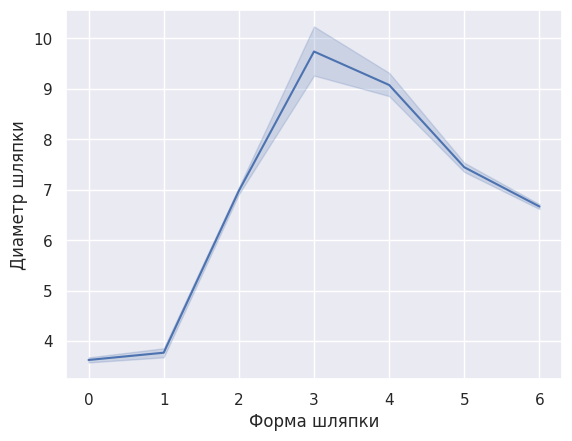

In [42]:
sns.lineplot(data=train, x='cap-shape', y='cap-diameter')
plt.xlabel('Форма шляпки')
plt.ylabel('Диаметр шляпки')

Text(0, 0.5, 'Диаметр шляпки')

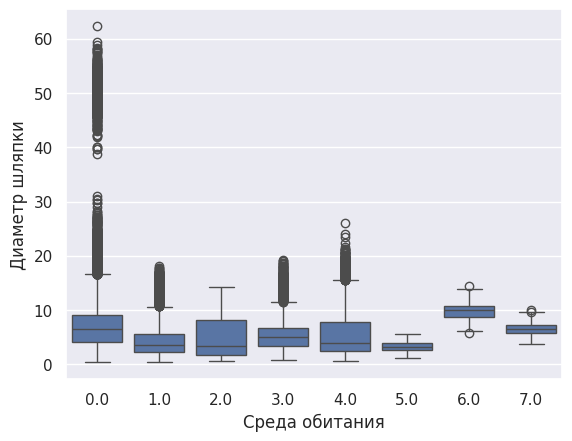

In [45]:
sns.boxplot(data=train, y='cap-diameter', x='habitat')
plt.xlabel('Среда обитания')
plt.ylabel('Диаметр шляпки')

Text(0, 0.5, 'Высота ножки')

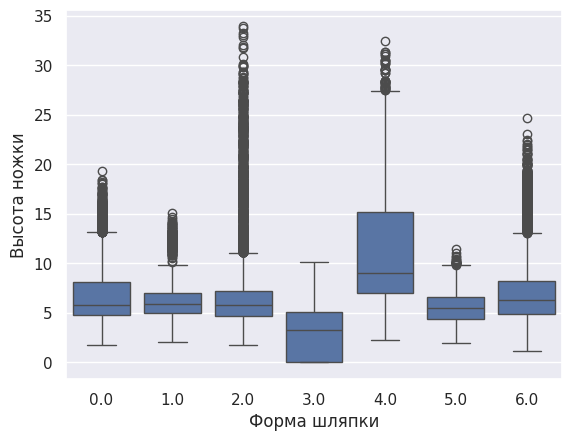

In [48]:
sns.boxplot(data=train, y='stem-height', x='cap-shape')
plt.xlabel('Форма шляпки')
plt.ylabel('Высота ножки')

Распределение съедобных и ядовитых грибов по среде обитания

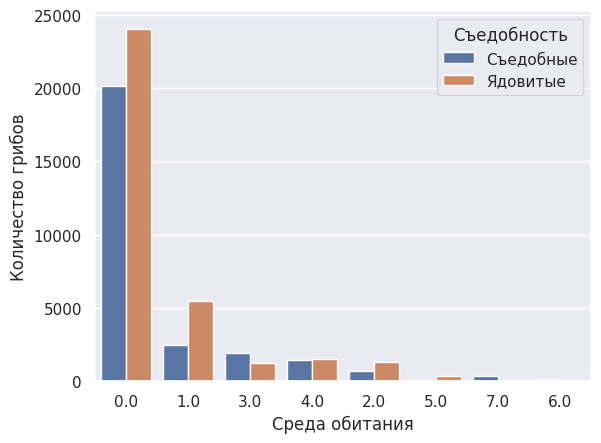

In [73]:
sns.countplot(data=train, x='habitat', hue='class',order=train['habitat'].value_counts().index)
plt.xlabel('Среда обитания')
plt.ylabel('Количество грибов')
plt.legend(title='Съедобность', labels=['Съедобные', 'Ядовитые'])

Групповые визуализации

Тепловая карта корреляции

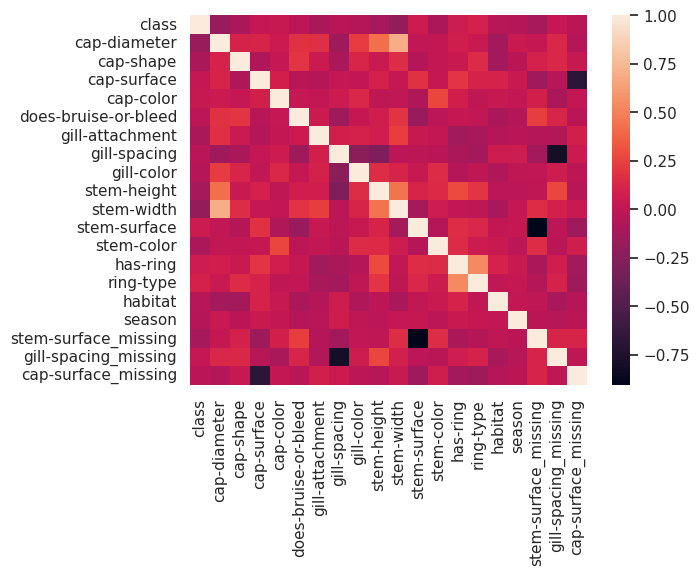

In [61]:
sns.heatmap(train.corr(numeric_only = True));

Парные взаимосвязи числовых признаков (зеленый - съедобный, красный - ядовитый)

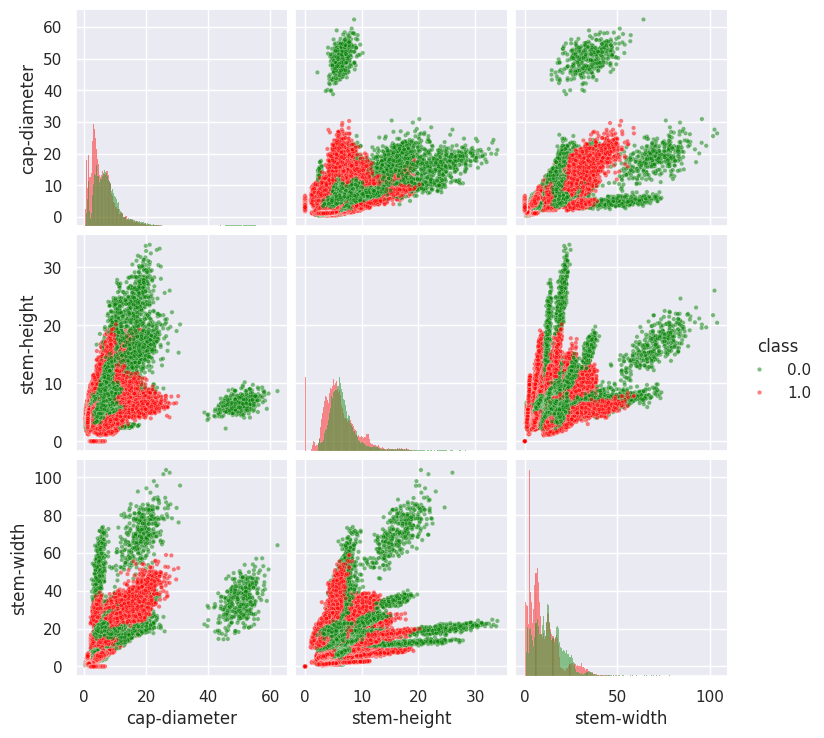

In [70]:
sns.pairplot(train,vars=['cap-diameter', 'stem-height', 'stem-width'], kind="scatter", hue="class", palette={0: 'green', 1: 'red'}, diag_kind="hist", plot_kws={'alpha': 0.5, 's': 10})